### Imports

In [31]:
import itertools
import random
import uuid

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from utils.streaming.factories import (
    create_dataset,
    create_model,
    create_pipeline,
    create_transformer,
)


pd.set_option('display.max_rows', None)


TS_COL = 'time:timestamp'
CASE_COL = 'case:concept:name'
ACTIVITY_COL = 'concept:name'

### Basic functions

In [2]:
def get_prefix_df(df, prefix_length):
    records = []
    for _, group in df.groupby(CASE_COL):
        activities = group[ACTIVITY_COL].tolist()

        for i in range(len(activities) - prefix_length):
            prefix = tuple(activities[i : i + prefix_length])
            next_activity = activities[i + prefix_length]
            records.append(
                {
                    'prefix': str(prefix),
                    'next_activity': next_activity,
                }
            )
    prefix_df = pd.DataFrame(records)

    return prefix_df


def get_trace_length(log_df: pd.DataFrame):
    trace_lengths = log_df.groupby(CASE_COL).size()
    return trace_lengths.tolist()


def get_trace_length_distribution(
    log_df: pd.DataFrame, dataset_name: str | None = None
):
    lengths = get_trace_length(log_df)

    plt.figure(figsize=(10, 6))
    plt.hist(
        lengths,
        bins=range(min(lengths), max(lengths) + 2),
        color='skyblue',
        edgecolor='black',
        alpha=0.7,
    )

    percentiles = [
        {
            'label': '80% Percentile',
            'value': np.percentile(lengths, 80),
            'color': 'red',
            'linestyle': 'dashed',
        },
        {
            'label': '90% Percentile',
            'value': np.percentile(lengths, 90),
            'color': 'orange',
            'linestyle': 'dashed',
        },
        {
            'label': '95% Percentile',
            'value': np.percentile(lengths, 95),
            'color': 'purple',
            'linestyle': 'dashed',
        },
        {
            'label': 'Median',
            'value': np.median(lengths),
            'color': 'green',
            'linestyle': 'dotted',
        },
    ]

    for p in percentiles:
        plt.axvline(
            p['value'],
            color=p['color'],
            linestyle=p['linestyle'],
            linewidth=2,
            label=f'{p["label"]} ({int(p["value"])})',
        )

    plt.title(f'Trace Length Distribution: {dataset_name}')
    plt.xlabel('Number of Events (Trace Length)')
    plt.ylabel('Frequency (Number of Traces)')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()


def traces_to_log_df(trace_fn, *args, start_timestamp='2020-01-01', **kwargs):
    traces = trace_fn(*args, **kwargs)

    records = []
    timestamp = pd.Timestamp(start_timestamp)

    for _, case_activities in enumerate(traces):
        case_id = str(uuid.uuid4())[-8:]
        for activity in case_activities:
            timestamp += pd.Timedelta(hours=1)
            records.append(
                {
                    CASE_COL: case_id,
                    ACTIVITY_COL: activity,
                    TS_COL: timestamp,
                }
            )

    return pd.DataFrame(records)

In [9]:
def get_task_cfg():
    return {
        'type': 'next_activity',
        'mode': 'predict_and_learn',
    }


def get_model_cfg(embedding_dim, sequence_window, feature_size, n_classes, init_size):
    return {
        'type': 'darwin_classifier',
        'params': {
            'embedding_dim': embedding_dim,
            'w2v_window': 5,
            'sequence_window': sequence_window,
            'feature_size': feature_size,
            'batch_size': 32,
            'dynamic_n_classes': True,
            'n_classes': n_classes,
            'max_n_classes': 20,
            'epochs': 30,
            'init_size': init_size,
            'sequence_model': {
                'type': 'lstm',
                'hidden_dim': 32,
                'num_layers': 1,
                'dropout': 0.01,
            },
            'optimizer': {'type': 'nadam', 'lr': 0.01},
            'loss_fn': {'type': 'cross_entropy'},
            'drift_detector': {'type': 'none'},
        },
    }


def get_dataset_cfg(log_df):
    return {
        'source': 'data_frame',
        'data_frame': log_df,
        'terminator': {'type': 'oracle'},
    }


def get_transformer_cfg():
    return {'type': 'darwin'}


### Chaos log

In [3]:
def generate_chaos_traces(
    num_cases,
    activities,
    min_len,
    mean_len,
    max_len,
    std_len,
    seed=123,
):
    np.random.seed(seed)

    traces = []

    for _ in range(num_cases):
        case_length = int(
            np.clip(np.random.normal(mean_len, std_len), min_len, max_len)
        )
        case_activities = np.random.choice(activities, size=case_length, replace=True)
        traces.append(case_activities.tolist())

    return traces

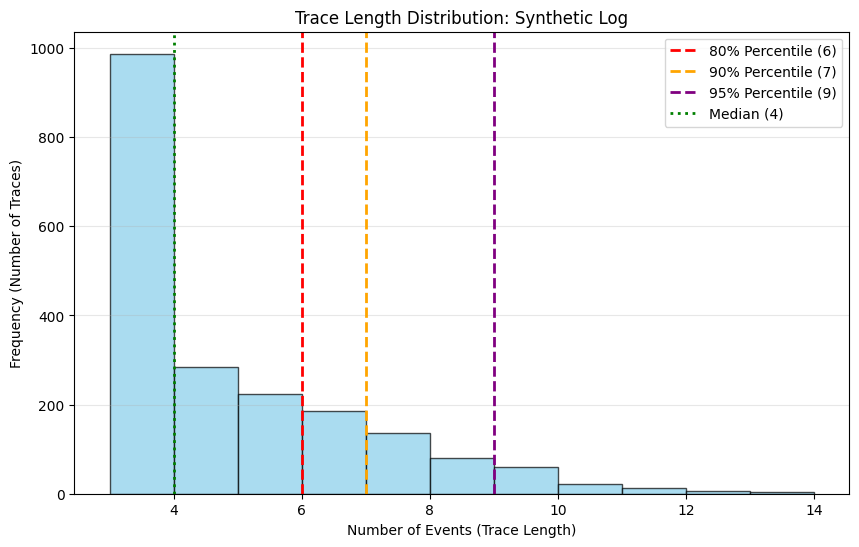

In [23]:
log_df = traces_to_log_df(
    generate_chaos_traces,
    num_cases=2000,
    activities=['A', 'B', 'C', 'D'],
    min_len=3,
    mean_len=4,
    max_len=15,
    std_len=3,
    seed=42,
)

get_trace_length_distribution(log_df, dataset_name='Synthetic Log')

for prefix_len in [3, 4, 5, 6, 7]:
    prefix_df = get_prefix_df(log_df, prefix_length=prefix_len)
    if prefix_df.empty:
        print(f'Prefix Length: {prefix_len}, No data available')
        continue

    # u_value = calculate_theils_u(prefix_df)

    # print(f"Prefix Length: {prefix_len}, Theil's U: {u_value:.4f}")

### Local Stochasticity


In [ ]:
def get_traces(num_cases):
    traces = []
    for _ in range(num_cases):
        if np.random.rand() > 0.5:
            traces.append(['A', 'B', 'C', 'D', 'E'])
        else:
            traces.append(['A', 'B', 'X', 'Y', 'Z'])
    return traces


In [ ]:
def get_traces(num_cases):
    traces = []
    for _ in range(num_cases):
        if np.random.rand() > 0.5:
            traces.append(['P1', 'A', 'B', 'C'])
        else:
            traces.append(['P2', 'A', 'B', 'X'])
    return traces


In [ ]:
def get_traces_patterns():
    activities = ['A', 'B', 'C', 'D']
    end_act = 'E'
    train_ratio = 0.7

    all_unique = [list(p) + [end_act] for p in itertools.permutations(activities)]
    random.shuffle(all_unique)

    split_idx = int(len(all_unique) * train_ratio)
    train_patterns = all_unique[:split_idx]
    test_patterns = all_unique[split_idx:]

    print(f'Total Unique Permutations: {len(all_unique)}')
    print(
        f'Training on {len(train_patterns)} patterns. Testing on {len(test_patterns)} unseen patterns.'
    )

    return train_patterns, test_patterns


def get_traces(num_cases, patterns):
    traces = patterns * (num_cases // len(patterns) + 1)
    random.shuffle(traces)
    return traces[:num_cases]

In [57]:
# train_log_df = traces_to_log_df(get_traces, num_cases=200)
# test_log_df = traces_to_log_df(get_traces, num_cases=100)


train_patterns, test_patterns = get_traces_patterns()
train_log_df = traces_to_log_df(get_traces, num_cases=200, patterns=train_patterns)
test_log_df = traces_to_log_df(get_traces, num_cases=100, patterns=test_patterns)

Total Unique Permutations: 24
Training on 16 patterns. Testing on 8 unseen patterns.


In [ ]:
unique_events = train_log_df[ACTIVITY_COL].unique()
num_events = len(train_log_df)

embedding_dim = 4
feature_size = 0
sequence_window = 4
n_classes = len(unique_events)
init_size = num_events * 0.1

task_cfg = get_task_cfg()
model_cfg = get_model_cfg(
    embedding_dim, sequence_window, feature_size, n_classes, init_size
)
dataset_cfg = get_dataset_cfg(train_log_df)
transformer_cfg = get_transformer_cfg()

dataset_kwargs, source, terminator, allowed_events = create_dataset(dataset_cfg)
model = create_model(model_cfg)
transformer = create_transformer(transformer_cfg)
pipeline = create_pipeline(
    task_cfg,
    model=model,
    transformer=transformer,
    terminator=terminator,
    source_mode=source,
)

results_df, model, _ = pipeline.run(**dataset_kwargs)

In [59]:
results_df.tail(20)

,trace_id,trace_n,event_n,event_name,event_time,y_true,y_pred,n_pred,n_drifts,drift_detected,prefix_len,loss,accuracy,macro_f1
980,ab9457ff,197,981,D,2020-02-10 21:00:00,D,None,784,0,False,1,0.847249,0.593567,0.576190
981,ab9457ff,197,982,C,2020-02-10 22:00:00,C,C,785,0,False,2,0.847249,0.594161,0.576932
982,ab9457ff,197,983,B,2020-02-10 23:00:00,B,B,786,0,False,3,0.847249,0.594752,0.577492
983,ab9457ff,197,984,A,2020-02-11 00:00:00,A,E,787,0,False,4,0.847249,0.593886,0.576625
984,ab9457ff,197,985,E,2020-02-11 01:00:00,E,E,788,0,False,5,0.847249,0.594477,0.576714
985,6c2152c1,198,986,C,2020-02-11 02:00:00,C,None,788,0,False,1,0.847249,0.594477,0.576714
986,6c2152c1,198,987,D,2020-02-11 03:00:00,D,C,789,0,False,2,0.847249,0.593614,0.576086
987,6c2152c1,198,988,A,2020-02-11 04:00:00,A,B,790,0,False,3,0.847249,0.592754,0.575035
988,6c2152c1,198,989,B,2020-02-11 05:00:00,B,B,791,0,False,4,0.847249,0.593343,0.575589
989,6c2152c1,198,990,E,2020-02-11 06:00:00,E,E,792,0,False,5,0.847249,0.593931,0.575676


In [ ]:
test_dataset_cfg = get_dataset_cfg(test_log_df)

test_dataset_kwargs, _, _, _ = create_dataset(test_dataset_cfg)
test_transformer = create_transformer(transformer_cfg)

pipeline = create_pipeline(
    task_cfg,
    model=model,
    transformer=test_transformer,
    terminator=terminator,
    source_mode=source,
)

test_results_df, test_model, _ = pipeline.run(**test_dataset_kwargs)

In [63]:
test_results_df[test_results_df['y_true'] == 'E']

test_results_df.tail()

,trace_id,trace_n,event_n,event_name,event_time,y_true,y_pred,n_pred,n_drifts,drift_detected,prefix_len,loss,accuracy,macro_f1
495,baa09ee9,100,496,D,2020-01-21 16:00:00,D,None,396,0,False,1,0.847249,0.436869,0.337207
496,baa09ee9,100,497,B,2020-01-21 17:00:00,B,C,397,0,False,2,0.847249,0.435768,0.336976
497,baa09ee9,100,498,C,2020-01-21 18:00:00,C,C,398,0,False,3,0.847249,0.437186,0.338106
498,baa09ee9,100,499,A,2020-01-21 19:00:00,A,E,399,0,False,4,0.847249,0.436090,0.337386
499,baa09ee9,100,500,E,2020-01-21 20:00:00,E,E,400,0,False,5,0.847249,0.437500,0.337651


### Uncertainty Coefficient (Theil's U)


In [ ]:
import string

import pandas as pd
from scipy.stats import entropy
from sklearn.metrics import accuracy_score, f1_score, mutual_info_score


def calculate_theils_u(x, y):
    x = pd.Series(x)
    y = pd.Series(y)

    mi = mutual_info_score(x, y)
    prob_x = x.value_counts(normalize=True)
    h_x = entropy(prob_x)

    return mi / h_x if h_x > 0 else 1.0


def get_prefixes(sequence, prefix_len=3):
    prefixes = []
    targets = []
    for i in range(len( ) - prefix_len):
        prefix_tuple = tuple(sequence[i : i + prefix_len])
        prefixes.append(str(prefix_tuple))
        targets.append(sequence[i + prefix_len])
    return prefixes, targets


def get_predictions(prefixes, targets):
    df = pd.DataFrame({'prefix': prefixes, 'target': targets})
    optimal_prediction_map = (
        df.groupby('prefix')['target'].apply(lambda x: x.mode().iloc[0]).to_dict()
    )
    return [optimal_prediction_map[p] for p in prefixes]

In [81]:
def get_structured_log(patterns, log_size):
    sequence = []
    while len(sequence) < log_size:
        sequence.extend(random.choice(patterns))
    return sequence[:log_size]


def get_noise_prefixes(alphabet, log_size, prefix_len, noise_ratio=0.3, seed=42):
    np.random.seed(seed)
    prefixes = []
    targets = []

    base_pattern = ['A', 'B', 'C']
    history_cycle = [base_pattern[i % 3] for i in range(log_size + 10)]

    for i in range(log_size - prefix_len):
        prefix = tuple(history_cycle[i : i + prefix_len])

        last_activity = prefix[-1]

        if np.random.rand() > noise_ratio:
            # Semi-deterministic rule: A->B, B->C, C->A
            if last_activity == 'A':
                target = 'B'
            elif last_activity == 'B':
                target = 'C'
            else:
                target = 'A'
        else:
            # Pure noise injection
            target = np.random.choice(alphabet)

        prefixes.append(str(prefix))
        targets.append(target)

    return prefixes, targets

In [34]:
def plot_dataset_grid(
    plot_data,
    x_var='prefix_lens',
    y_vars=None,
    x_label='Prefix Length',
    y_labels=None,
    samples_df=None,
):
    y_vars = y_vars or ['f1_scores', 'u_vals']

    y_labels = y_labels or ['Macro F1', "Theil's U"]

    n_plots = len(plot_data)
    n_cols = min(6, n_plots)
    n_rows = int(np.ceil(n_plots / 6))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(6 * n_cols, 6 * n_rows),
    )

    axes = np.array(axes).reshape(-1) if n_plots > 1 else np.array([axes])

    for idx, (dataset_name, data) in enumerate(plot_data.items()):
        x_vals = data.get(x_var, [])
        ax = axes[idx]

        # Sample counts
        if samples_df is not None and dataset_name in samples_df.index:
            event_counts = []
            for xv in x_vals:
                try:
                    event_counts.append(int(samples_df.loc[dataset_name, int(xv)]))
                except Exception:
                    event_counts.append(0)
            event_counts = np.array(event_counts, dtype=float)
            max_cnt = event_counts.max() if event_counts.size else 0
            if max_cnt > 0:
                event_counts_norm = event_counts / max_cnt
            else:
                event_counts_norm = event_counts  # zeros
            ax.bar(
                x_vals,
                event_counts_norm,
                color='gray',
                alpha=0.15,
                width=0.6,
                zorder=0,
            )

        for y_var, y_label in zip(y_vars, y_labels, strict=True):
            if y_var not in data:
                continue

            y_vals = data.get(y_var, [])

            if y_vals:
                ax.plot(
                    x_vals,
                    y_vals,
                    marker='o',
                    label=y_label,
                    linewidth=2,
                    markersize=8,
                    zorder=1,
                )

        ax.set_xlabel(x_label)
        ax.set_ylabel('Score')
        ax.set_title(dataset_name)
        ax.set_ylim(0, 1.1)
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best')
        ax.set_xticks(x_vals)

    for idx in range(n_plots, len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()

In [88]:
np.random.seed(42)
log_size = 20000

alphabet = list(string.ascii_uppercase)

# Dataset A: Structured Rules (High Theil's U)
pattern_len = 9
patterns = [alphabet[:pattern_len], alphabet[-pattern_len:]]
structured_log = get_structured_log(patterns, log_size)

# Dataset B: pure random noise (Low Theil's U)
unique_events = 6
noise_alphabet = alphabet[:unique_events]

results = {'high_u': [], 'low_u': []}

for prefix_len in [3, 4, 5, 6, 7]:
    prefix_high, target_high = get_prefixes(structured_log, prefix_len=prefix_len)
    prefix_low, target_low = get_noise_prefixes(
        noise_alphabet, log_size, prefix_len, noise_ratio=0.1, seed=42
    )

    u_high = calculate_theils_u(target_high, prefix_high)
    u_low = calculate_theils_u(target_low, prefix_low)

    pred_high = get_predictions(prefix_high, target_high)
    acc_high = accuracy_score(target_high, pred_high)
    fscore_high = f1_score(target_high, pred_high, average='macro')

    pred_low = get_predictions(prefix_low, target_low)
    acc_low = accuracy_score(target_low, pred_low)
    fscore_low = f1_score(target_low, pred_low, average='macro')

    results['high_u'].append(
        {
            'prefix_len': prefix_len,
            'samples_num': len(prefix_high),
            'u_val': u_high,
            'accuracy': acc_high,
            'f1_score': fscore_high,
        }
    )
    results['low_u'].append(
        {
            'prefix_len': prefix_len,
            'samples_num': len(prefix_low),
            'u_val': u_low,
            'accuracy': acc_low,
            'f1_score': fscore_low,
        }
    )


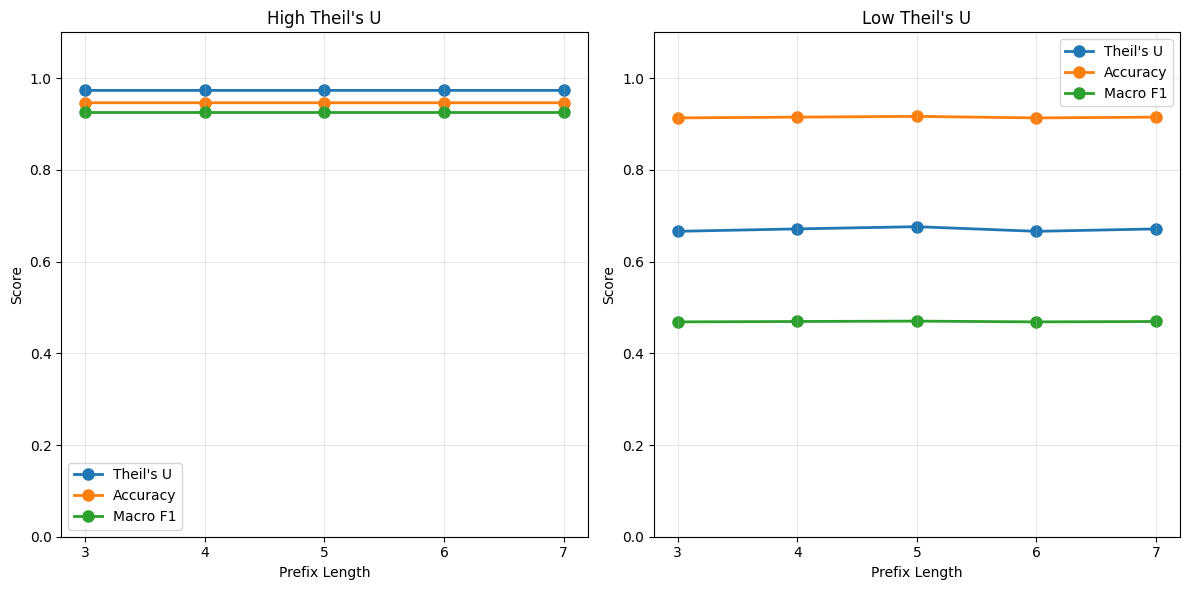

In [89]:
plot_data = {
    "High Theil's U": {
        'prefix_lens': [r['prefix_len'] for r in results['high_u']],
        'samples_num': [r['samples_num'] for r in results['high_u']],
        'u_vals': [r['u_val'] for r in results['high_u']],
        'accuracies': [r['accuracy'] for r in results['high_u']],
        'f1_scores': [r['f1_score'] for r in results['high_u']],
    },
    "Low Theil's U": {
        'prefix_lens': [r['prefix_len'] for r in results['low_u']],
        'samples_num': [r['samples_num'] for r in results['low_u']],
        'u_vals': [r['u_val'] for r in results['low_u']],
        'accuracies': [r['accuracy'] for r in results['low_u']],
        'f1_scores': [r['f1_score'] for r in results['low_u']],
    },
}

plot_dataset_grid(
    plot_data,
    x_var='prefix_lens',
    y_vars=['u_vals', 'accuracies', 'f1_scores'],
    x_label='Prefix Length',
    y_labels=["Theil's U", 'Accuracy', 'Macro F1'],
)